In [1]:
# =============================================================================
# (1) IMPORTAÇÃO DAS BIBLIOTECAS
# =============================================================================
# carregar todas as ferramentas usadas no experimento.
import pandas as pd            # pandas: manipular tabelas (DataFrame) e ler o CSV
import numpy as np             # numpy: cálculos numéricos com vetores e matrizes
# import matplotlib            # (opcional) backend sem interface grafica...
# matplotlib.use("Agg")        # ...util para salvar figuras em servidores sem tela
import matplotlib.pyplot as plt        # matplotlib: criacao dos gráficos (Figura 1)
from sklearn.impute import KNNImputer  # KNNImputer: imputação por vizinhos mais proximos (KNN)

In [2]:
# =============================================================================
# (2) LEITURA DOS DADOS
# =============================================================================
# Caminho do arquivo com os dados já organizados do SEMAE-Piracicaba.
CAMINHO = "data/interim/dados_organizados.csv"

df = pd.read_csv(CAMINHO)   # lê o CSV e guarda numa tabela chamada df
df                          # exibe a tabela na tela (última linha da celula = mostrar o conteúdo)

,Ano,Mes,Calc,COR(ppm Pt Co),TURB.(FTU),pH,ALC.(ppm CaCO3),AC.(ppm CaCO3),O.C.(ppm O2),DBO(ppm O2),...,P(ppm P),Cond.(uS/cm),Amonia(mg/l),Surfact.(mg/l),Cianobacteria(cel/ml),S.T.(mg/l),C.T.(NMP/100ml),C.F.(NMP/100ml),CLOROFILA(ug/l),F(ppm F)
0,2009,Jan,Mín.,200.0,64.0,"7,0",29,3,"6,3",--,...,--,131,NaN,--,6.600,--,50.000,23.000,"2,23","0,12"
1,2009,Jan,Méd.,432.0,131.0,"7,2",34,5,"6,8",--,...,--,145,NaN,--,6.850,--,50.000,23.000,"11,35","0,16"
2,2009,Jan,Máx.,690.0,241.0,"7,4",38,8,"7,5",--,...,--,156,NaN,--,7.100,--,50.000,23.000,"22,32","0,19"
3,2009,Fev,Mín.,393.0,72.0,"6,5",29,6,"5,9",--,...,--,128,NaN,--,1.100,--,240.000,30.000,"6,69","0,12"
4,2009,Fev,Méd.,868.0,238.0,"7,1",31,7,"7,2",--,...,--,133,NaN,--,2.100,--,240.000,30.000,"7,81","0,16"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,2024,Nov,Méd.,217.0,134.0,"7,5",48,9,"9,7",-,...,"0,06",263,"2,00",-,-,-,-,3.000,"38,68","0,32"
572,2024,Nov,Máx.,805.0,746.0,"7,8",60,18,"17,6",-,...,"0,06",439,"4,39",-,-,-,-,3.000,"38,68","0,42"
573,2024,Dez,Mín.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
574,2024,Dez,Méd.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# =============================================================================
# (3) - SELECIONAR APENAS A LINHA DE MÉDIA MENSAL
# =============================================================================
# A base traz várias estatísticas por mês (média, minimo, máximo, etc.),
# identificadas na coluna "Calc". Aqui ficamos so com a MÉDIA mensal ("Med."),
# que é a série usada no estudo (192 meses, 2009-2024).
#   df["Calc"] == "Med."  -> filtra as linhas de média
#   .copy()               -> cria cópia independente (evita avisos do pandas)
#   .reset_index(drop=True) -> renumera as linhas de 0 em diante
med = df[df["Calc"] == "Méd."].copy().reset_index(drop=True)

In [4]:
# =============================================================================
# (4) FUNÇÃO PARA CONVERTER NÚMEROS DO FORMATO BRASILEIRO
# =============================================================================
def to_num(s):
    """Converte texto no formato brasileiro ('1.110', '6,3', '--') para float."""
    # Passo a passo:
    #   str(s).strip()   -> garante texto e remove espaÇos das pontas
    #   .replace(".", "") -> remove o ponto de MILHAR   ('1.110' -> '1110')
    #   .replace(",", ".") -> troca a vírgula DECIMAL por ponto ('6,3' -> '6.3')
    s = str(s).strip().replace(".", "").replace(",", ".")
    try:
        return float(s)        # tenta converter para número real
    except ValueError:
        return np.nan          # se não der (ex.: '--'), marca como vazio (NaN = dado ausente)

In [5]:
# =============================================================================
# (5) VARIÁVEIS PREDITORAS E MONTAGEM DA "BASE-VERDADE" (PADRÃO-OURO)
# =============================================================================
# Lista das 12 variáveis físico-quimícas que o KNN usa como pistas (preditoras).
PRED = [
    "COR(ppm Pt Co)", "TURB.(FTU)", "pH", "ALC.(ppm CaCO3)", "AC.(ppm CaCO3)",
    "O.C.(ppm O2)", "O.D.(ppm O2)", "Cl-(ppm Cl-)", "DUR.(ppm CaCO3)",
    "Fe(ppm Fe)", "Mn(mg/l)", "Cond.(uS/cm)",
]

# Pega essas 12 colunas da média mensal e converte TODAS para número (funcao to_num).
X = med[PRED].apply(lambda c: c.map(to_num))

# Mantém apenas os meses SEM nenhum vazio nessas 12 variáveis (X.dropna()).
# Esses meses 100% completos formam o "gabarito" (padrao-ouro): como nada falta,
# podemos apagar valores de propósito e depois conferir se o método acertou.
full = X.dropna().reset_index(drop=True)
print(f"Meses completos (base-verdade): {len(full)}")   # quantos meses completos sobraram

Meses completos (base-verdade): 176


In [6]:
# Versão do df com TODAS as colunas de medição convertidas para número (só para visualizar)
nao_medicao = ["Ano", "Mes", "Calc"]                 # colunas que não são medições
cols_medicao = [c for c in df.columns if c not in nao_medicao]
df_num = df.copy()
df_num[cols_medicao] = df_num[cols_medicao].apply(lambda c: c.map(to_num))
df_num # agora tudo com ponto

,Ano,Mes,Calc,COR(ppm Pt Co),TURB.(FTU),pH,ALC.(ppm CaCO3),AC.(ppm CaCO3),O.C.(ppm O2),DBO(ppm O2),...,P(ppm P),Cond.(uS/cm),Amonia(mg/l),Surfact.(mg/l),Cianobacteria(cel/ml),S.T.(mg/l),C.T.(NMP/100ml),C.F.(NMP/100ml),CLOROFILA(ug/l),F(ppm F)
0,2009,Jan,Mín.,2000.0,640.0,7.0,29.0,3.0,6.3,NaN,...,NaN,131.0,NaN,NaN,6600.0,NaN,50000.0,23000.0,2.23,0.12
1,2009,Jan,Méd.,4320.0,1310.0,7.2,34.0,5.0,6.8,NaN,...,NaN,145.0,NaN,NaN,6850.0,NaN,50000.0,23000.0,11.35,0.16
2,2009,Jan,Máx.,6900.0,2410.0,7.4,38.0,8.0,7.5,NaN,...,NaN,156.0,NaN,NaN,7100.0,NaN,50000.0,23000.0,22.32,0.19
3,2009,Fev,Mín.,3930.0,720.0,6.5,29.0,6.0,5.9,NaN,...,NaN,128.0,NaN,NaN,1100.0,NaN,240000.0,30000.0,6.69,0.12
4,2009,Fev,Méd.,8680.0,2380.0,7.1,31.0,7.0,7.2,NaN,...,NaN,133.0,NaN,NaN,2100.0,NaN,240000.0,30000.0,7.81,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,2024,Nov,Méd.,2170.0,1340.0,7.5,48.0,9.0,9.7,NaN,...,0.06,263.0,2.00,NaN,NaN,NaN,NaN,3000.0,38.68,0.32
572,2024,Nov,Máx.,8050.0,7460.0,7.8,60.0,18.0,17.6,NaN,...,0.06,439.0,4.39,NaN,NaN,NaN,NaN,3000.0,38.68,0.42
573,2024,Dez,Mín.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
574,2024,Dez,Méd.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# =============================================================================
# (6) PARÂMETROS DO EXPERIMENTO E FUNÇÃO DE MÉTRICAS
# =============================================================================
ALVOS = ["COR(ppm Pt Co)", "TURB.(FTU)"]      # variáveis cuja recuperação será avaliada (esse é um exemplo)
NIVEIS = [0.10, 0.20, 0.30]                   # taxas de falha simulada: 10%, 20%, 30% (MCAR)
REPS = 30                                     # repetições por cenário (estabilidade estatística)


def metricas(y_true, y_pred):
    """RMSE, MAE e R² na escala original."""
    # Compara os valores imputados (y_pred) com os valores reais (y_true).
    e = y_pred - y_true                          # erro de cada ponto (previsto - verdadeiro)
    rmse = np.sqrt(np.mean(e ** 2))              # RMSE: raiz do erro quadrático médio (pune erros grandes)
    mae = np.mean(np.abs(e))                     # MAE: erro absoluto médio (erro tipico)
    ss = np.sum((y_true - y_true.mean()) ** 2)   # variação total dos dados reais
    # R2: 1 = perfeito | 0 = igual a chutar a média | < 0 = PIOR que chutar a media
    r2 = 1 - np.sum(e ** 2) / ss if ss > 0 else np.nan
    return rmse, mae, r2

In [8]:
# =============================================================================
# (7) MASCARAR -> IMPUTAR -> MEDIR
# =============================================================================
# Ideia central: para cada variável-alvo, cada nível de falha e cada método,
# escondemos valores de propósito (sorteio aleatório = MCAR), preenchemos com o
# método e comparamos com o valor verdadeiro. Repetimos 30x e tiramos a média.

linhas = []                                  # guardara o resultado de cada cenário
for alvo in ALVOS:                           # percorre COR e depois TURB.
    col = full.columns.get_loc(alvo)         # posição (índice) da coluna do alvo na matriz
    y = full[alvo].values                    # valores VERDADEIROS do alvo (o gabarito)
    n = len(y)                               # quantidade de meses completos
    rng_var = y.max() - y.min()              # amplitude (max - min): normaliza o erro para escala 0-1

    for p in NIVEIS:                         # percorre 10%, 20%, 30%
        k = max(1, int(round(p * n)))        # quantos valores esconder (no minimo 1)

        for metodo in ["media", "mediana", "KNN"]:   # os três métodos comparados
            R = []                                   # guardara (rmse, mae, r2) de cada repetição
            for r in range(REPS):                    # repete 30 vezes
                # Gerador aleatório com SEMENTE FIXA por (nível, repetição):
                # garante que o sorteio seja sempre o mesmo ao rodar de novo (reprodutibilidade).
                rng = np.random.default_rng(1000 * int(p * 100) + r) 
                mask = rng.choice(n, size=k, replace=False)  # células ESCONDIDAS -> papel de "teste"
                obs = np.setdiff1d(np.arange(n), mask)       # células VISÍVEIS -> papel de "treino/referência"

                if metodo == "media":
                    # Preenche TODOS os buracos com a MÉDIA dos valores visíveis.
                    imp = np.full(k, y[obs].mean())
                elif metodo == "mediana":
                    # Preenche TODOS os buracos com a MEDIANA dos valores visíveis.
                    imp = np.full(k, np.median(y[obs]))
                else:  # KNN multivariado
                    Xm = full.values.astype(float).copy()     # copia da matriz completa (as 12 variaveis)
                    Xm[mask, col] = np.nan                    # esconde SOMENTE as células-alvo sorteadas
                    mu = np.nanmean(Xm, axis=0)               # média de cada coluna (ignorando NaN)
                    sd = np.nanstd(Xm, axis=0); sd[sd == 0] = 1  # desvio de cada coluna (evita divisão por zero)
                    Xs = (Xm - mu) / sd                       # padroniza: cada variável com média 0 e desvio 1
                    # KNN estima cada vazio olhando os 7 meses mais parecidos nas OUTRAS variáveis
                    # (weights="distance": vizinhos mais próximos pesam mais).
                    Xi = KNNImputer(n_neighbors=7, weights="distance").fit_transform(Xs)
                    imp = (Xi * sd + mu)[mask, col]           # desfaz a padronizacao e pega so os valores estimados

                R.append(metricas(y[mask], imp))   # mede o acerto (imputado x verdadeiro que estava escondido)

            R = np.array(R)                        # matriz 30x3 (linhas=repeticoes; colunas=rmse,mae,r2)
            rmse, mae, r2 = R.mean(0)              # media das 30 repeticoes -> resultado do cenario
            r2_std = R[:, 2].std()                 # desvio-padrao do R2 (vira as barras de erro da Figura 1)
            linhas.append(dict(                    # salva o resultado deste cenario
                var=alvo.split("(")[0], nivel=int(p * 100), metodo=metodo,
                RMSE=rmse, MAE=mae, R2=r2, R2_std=r2_std,
                RMSE_n=rmse / rng_var, MAE_n=mae / rng_var,   # RMSE e MAE normalizados (0-1) -> usados na Tabela 1
            ))

res = pd.DataFrame(linhas)                         # junta todos os cenarios numa tabela
res.to_csv("resultados_exp_norm.csv", index=False) # salva a tabela de resultados (base da Tabela 1)
# imprime um resumo arredondado na tela:
print(res[["var", "nivel", "metodo", "RMSE_n", "MAE_n", "R2"]].round(3).to_string(index=False))

  var  nivel  metodo  RMSE_n  MAE_n     R2
  COR     10   media   0.129  0.091 -0.098
  COR     10 mediana   0.136  0.085 -0.197
  COR     10     KNN   0.080  0.041  0.604
  COR     20   media   0.127  0.089 -0.057
  COR     20 mediana   0.137  0.086 -0.207
  COR     20     KNN   0.078  0.040  0.610
  COR     30   media   0.122  0.087 -0.029
  COR     30 mediana   0.129  0.080 -0.147
  COR     30     KNN   0.076  0.039  0.614
TURB.     10   media   0.190  0.148 -0.086
TURB.     10 mediana   0.204  0.135 -0.219
TURB.     10     KNN   0.113  0.070  0.617
TURB.     20   media   0.191  0.144 -0.064
TURB.     20 mediana   0.207  0.134 -0.231
TURB.     20     KNN   0.123  0.076  0.552
TURB.     30   media   0.189  0.143 -0.013
TURB.     30 mediana   0.205  0.128 -0.190
TURB.     30     KNN   0.119  0.070  0.601


Figura salva


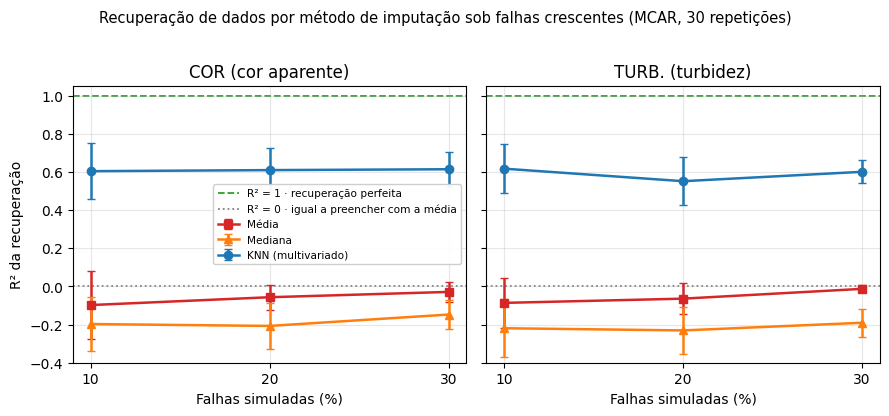

In [9]:
# =============================================================================
# (8) GERAÇÃO DA FIGURA 1 (R2 x % de falha)
# =============================================================================
# Dicionários de aparência: nome, cor, marcador e titulo de cada metodo/variavel.
labels = {"media": "Média", "mediana": "Mediana", "KNN": "KNN (multivariado)"}
cores = {"media": "#d62728", "mediana": "#ff7f0e", "KNN": "#1f77b4"}   # vermelho, laranja, azul
marc = {"media": "s", "mediana": "^", "KNN": "o"}                       # quadrado, triangulo, circulo
titulos = {"COR": "COR (cor aparente)", "TURB.": "TURB. (turbidez)"}

# Cria a figura com DOIS paineis lado a lado (COR e TURB.), com eixo Y compartilhado.
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharey=True)
for ax, v in zip(axes, ["COR", "TURB."]):          # para cada painel/variavel
    d = res[res["var"] == v]                       # filtra os resultados daquela variavel
    for m in ["media", "mediana", "KNN"]:          # desenha uma linha por metodo
        dm = d[d["metodo"] == m].sort_values("nivel")   # ordena por nivel de falha (10, 20, 30)
        # Linha do R2 x % de falha, com barras de erro (yerr = desvio-padrao do R2).
        ax.errorbar(dm["nivel"], dm["R2"], yerr=dm["R2_std"], marker=marc[m],
                    color=cores[m], label=labels[m], capsize=3, lw=1.8, ms=6, zorder=3)
    # --- linhas de referencia ---
    ax.axhline(1.0, color="#2ca02c", ls="--", lw=1.3, zorder=1,
               label="R² = 1 · recuperação perfeita")            # teto: imputado = real
    ax.axhline(0.0, color="gray", ls=":", lw=1.3, zorder=1,
               label="R² = 0 · igual a preencher com a média")   # abaixo daqui = pior que a média
    ax.set_title(titulos[v]); ax.set_xlabel("Falhas simuladas (%)")
    ax.set_xticks([10, 20, 30]); ax.grid(alpha=.3) # marca so 10/20/30 no eixo X e adiciona grade leve
    ax.set_ylim(-0.4, 1.05)                         # eixo padronizado ate 1 (mantendo os R2 negativos)
    ax.set_yticks(np.arange(-0.4, 1.01, 0.2))       # marcas de 0,2 em 0,2
axes[0].set_ylabel("R² da recuperação")            # rotulo do eixo Y (so no painel da esquerda)
axes[0].legend(fontsize=7.6, loc="center right", framealpha=0.95)  # metodos + linhas de referencia
fig.suptitle("Recuperação de dados por método de imputação sob falhas crescentes "
             "(MCAR, 30 repetições)", fontsize=10.5)   # titulo geral da figura
plt.tight_layout(rect=[0, 0, 1, 0.96])             # ajusta espacamentos (deixa espaco para o titulo)
plt.savefig("figura_imputacao.png", dpi=200, bbox_inches="tight")  # salva a Figura 1 em PNG (200 dpi)
print("Figura salva")

#### (EXTRA) Visualização do KNN — vizinhança e imputado × real

Usamos **PCA (2D) apenas para VISUALIZAR** os 176 meses; o KNN de fato opera nas 12 variáveis padronizadas (não nesses 2 componentes).

- **Esquerda:** um mês-exemplo (estrela) e seus **7 vizinhos mais próximos**: exatamente os meses que o KNN usa para preencher aquele valor. Não são clusters, e sim a vizinhança local daquele ponto.
- **Direita:** valores de COR que foram escondidos (**real**) contra o que o KNN estimou (**imputado**), no cenário de 20% de falha. Quanto mais perto da linha `y = x`, melhor.

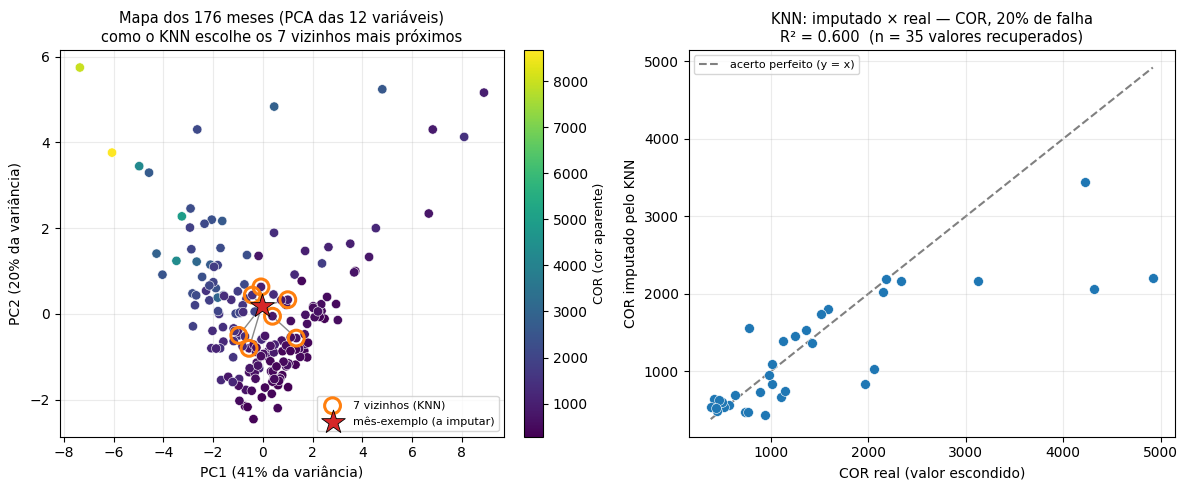

In [10]:
# =============================================================================
# VISUALIZAR O KNN: vizinhança (PCA 2D) e imputado x real
# -----------------------------------------------------------------------------
# OBS.: O algoritmo PCA aqui é SOMENTE para desenhar em 2D. O KNN trabalha nas 12 variaveis
# padronizadas. Depende de `full` (criado na célula da base-verdade) e de np/pd/plt.
# =============================================================================
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# padroniza as 12 variáveis (mesma lógica do experimento)
mu = full.values.mean(0); sd = full.values.std(0); sd[sd == 0] = 1
Xs = (full.values - mu) / sd
n = len(full)

# PCA em 2 dimensões (apenas para conseguir desenhar as 12 variáveis)
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xs)
var = pca.explained_variance_ratio_ * 100     # % de variancia de cada eixo

# exemplo: um mês central e seus 7 vizinhos mais próximos (em 12D) ---
nn = NearestNeighbors(n_neighbors=8).fit(Xs)                # 8 = o próprio ponto + 7 vizinhos
ex = int(np.argmin(np.linalg.norm(Z - Z.mean(0), axis=1)))  # escolhe um mês "central"
_, idx = nn.kneighbors(Xs[ex:ex+1])
viz = idx[0][1:]                                            # os 7 vizinhos (exclui o próprio ponto)
cor = full["COR(ppm Pt Co)"].values                         # cor dos pontos = valor de COR

# --- painel B: reproduz um cenario do experimento (COR, 20% de falha, 1 repeticao) ---
col = full.columns.get_loc("COR(ppm Pt Co)")
y = full["COR(ppm Pt Co)"].values
p = 0.20; k = int(round(p * n))
rng = np.random.default_rng(1000 * int(p * 100) + 0)   # mesma semente do experimento
mask = rng.choice(n, size=k, replace=False)
Xm = full.values.astype(float).copy(); Xm[mask, col] = np.nan
muu = np.nanmean(Xm, 0); sdd = np.nanstd(Xm, 0); sdd[sdd == 0] = 1
Xi = KNNImputer(n_neighbors=7, weights="distance").fit_transform((Xm - muu) / sdd)
imp = (Xi * sdd + muu)[mask, col]             # valores imputados nas celulas escondidas
true = y[mask]                                # valores reais correspondentes
r2 = 1 - np.sum((imp - true) ** 2) / np.sum((true - true.mean()) ** 2)

# ============================== FIGURA ==============================
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))

# Painel A: mapa dos meses (PCA) + vizinhanca do KNN
sc = axA.scatter(Z[:, 0], Z[:, 1], c=cor, cmap="viridis", s=45,
                 edgecolor="white", linewidth=0.4, zorder=2)
for j in viz:                                  # linha do exemplo ate cada vizinho
    axA.plot([Z[ex, 0], Z[j, 0]], [Z[ex, 1], Z[j, 1]], color="#888888", lw=1.0, zorder=1)
axA.scatter(Z[viz, 0], Z[viz, 1], s=130, facecolor="none", edgecolor="#ff7f0e",
            linewidth=2.2, zorder=3, label="7 vizinhos (KNN)")
axA.scatter(Z[ex, 0], Z[ex, 1], marker="*", s=320, color="#d62728", edgecolor="black",
            linewidth=0.6, zorder=4, label="mês-exemplo (a imputar)")
axA.set_xlabel(f"PC1 ({var[0]:.0f}% da variância)")
axA.set_ylabel(f"PC2 ({var[1]:.0f}% da variância)")
axA.set_title("Mapa dos 176 meses (PCA das 12 variáveis)\ncomo o KNN escolhe os 7 vizinhos mais próximos", fontsize=10.5)
axA.legend(fontsize=8, loc="best"); axA.grid(alpha=.25)
cb = fig.colorbar(sc, ax=axA, fraction=0.046, pad=0.04); cb.set_label("COR (cor aparente)", fontsize=9)

# Painel B: imputado x real
axB.scatter(true, imp, s=50, color="#1f77b4", edgecolor="white", linewidth=0.4, zorder=2)
lo = min(true.min(), imp.min()); hi = max(true.max(), imp.max())
axB.plot([lo, hi], [lo, hi], ls="--", color="gray", lw=1.5, zorder=1, label="acerto perfeito (y = x)")
axB.set_xlabel("COR real (valor escondido)"); axB.set_ylabel("COR imputado pelo KNN")
axB.set_title(f"KNN: imputado × real — COR, 20% de falha\nR² = {r2:.3f}  (n = {k} valores recuperados)", fontsize=10.5)
axB.legend(fontsize=8, loc="best"); axB.grid(alpha=.25)

plt.tight_layout()
import os
os.makedirs("reports/figures", exist_ok=True)
plt.savefig("reports/figures/knn_vizinhanca.png", dpi=200, bbox_inches="tight")
plt.show()